# Combined Diamond + Eikosany Optimisation

Studies how many nodes of the Penrose tiling — at the canonical shift
`ω₁ = (4/5, −1/5, −1/5, −1/5, −1/5)`, the first (minuscule) fundamental weight of A₄ —
can be made members of the **Hexadic Diamond** or of the **141-point Eikosany
difference set** (see the note on terminology below), by applying a single scalar
frequency multiplier `r` to every node ratio.

The main deliverable is `Data/ji_membership.json`: the optimal scalar
(`freqRatioScalar`) plus the 2D positions of the matched Diamond / Eikosany-set
nodes, consumed by `tiling.scd` and `tiling_simple.scd`.

Membership tests use log-arithmetic instead of SymPy for speed: each node's
fingerprint `(pt5 · log rᵢ) mod log 2` is compared against precomputed target
fingerprints with tolerance 1e-7.

A preliminary section also searches over zero-trace `shiftVector`s with
`differential_evolution`, regenerating `selPoints` from the full 7⁵ integer grid
for every trial — but its optimum abandons the ω₁ geometry and is not used
downstream.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
from scipy.optimize import differential_evolution
import matplotlib.pyplot as plt
from sympy import Rational

import json

from ji_tiling import (
    in_hull,
    setup_a4_projection, make_acceptance_hull, make_int_grid,
    DIAMOND_RATIOS, he_representable,
)

## Projection setup

Identical to `penrose5D.ipynb`: cyclic permutation matrix → eigenvectors →
2D projection `p` (E∥) and 3D projection `y` (E⊥ + [1,1,1,1,1]).

In [2]:
eigenVectors, p, y = setup_a4_projection()

2D projection plane (E∥):
-->5D basis vectors are rotated in 2D plane by (2.0π)/5
3D acceptance-window space (E⊥ + uniform):
-->5D basis vectors are rotated in 2D plane by (4.0π)/5


## Convex hull (acceptance window)

In [3]:
hull, hull_del = make_acceptance_hull(y)
print(f'Hull vertices: {len(hull.vertices)}')

Hull vertices: 22


## Diamond ratios and starting shift vector

In [4]:
diamond_ratios = set(Rational(n, d) for n, d in DIAMOND_RATIOS)
print(f'Diamond ratios loaded from DIAMOND_RATIOS: {len(diamond_ratios)}')

# Starting guess 
# shiftVector = np.array([-0.36844, -0.491094, 0.315972, 0.430247, 0.113314])
shiftVector = np.array([4/5, -1/5, -1/5, -1/5, -1/5])

print(f'Starting shiftVector: {np.round(shiftVector, 6)}')

Diamond ratios loaded from DIAMOND_RATIOS: 29
Starting shiftVector: [ 0.8 -0.2 -0.2 -0.2 -0.2]


In [5]:
# Load the 141-point construction: the difference set E - E of the Eikosany
# (31 Diamond + 80 outer-ring + 30 inner-ring points), developed in pentadic.ipynb.
# Written by the export cell at the end of notebooks/pentadic.ipynb.
with open('../Data/eikosany_diamond.json', 'r') as file:
    eikos_ALL = json.load(file)

### What "Eikosany" means in this notebook

`Data/eikosany_diamond.json` holds the **141-point construction** (31 Diamond +
80 outer-ring + 30 inner-ring points) — the difference set $E - E$ of the Eikosany
developed in `pentadic.ipynb` — *not* the 20-note Eikosany itself (whose direct
computation is left commented out below).  Its non-Diamond values are **intervals
between Eikosany notes**.  Throughout this notebook, and in the `eikosany*` keys of
`Data/ji_membership.json` (hence `~eikosanyNodes` in `tiling.scd` /
`tiling_simple.scd`), "Eikosany" is shorthand for this 141-point difference set
with the Diamond values removed.

## Optimisation

In [6]:
from itertools import combinations

rI_float = np.array([3., 5., 7., 9., 11.])
log2     = np.log(2.0)
log_rI   = np.log(rI_float)

def _norm(x):
    """Normalise a positive ratio into [1, 2)."""
    while x >= 2.0: x /= 2.0
    while x < 1.0:  x *= 2.0
    return x

# --- Precompute Diamond real values in [1, 2) ---
diamond_float = np.array(sorted(set(_norm(float(r)) for r in diamond_ratios)))

# --- Precompute Eikosany real values in [1, 2) ---
# Generators {1,3,5,7,9,11}; choose 3.  "1" contributes no factor,
# so products with "1" are 2-element products of {3,5,7,9,11}.
# Encoded as {0,1}^5 vectors with sum 2 or 3 (indices into rI_float).
# eiko_float = sorted(set(
#     _norm(np.prod(rI_float[list(idx)]))
#     for r in (2, 3)
#     for idx in combinations(range(5), r)
# ))
# eiko_float = np.array(eiko_float)

eiko_float = np.sort(np.array(eikos_ALL['num'])/np.array(eikos_ALL['den']))
mask = np.isin(eiko_float,diamond_float)
eiko_float = eiko_float[~mask]

# --- Combined log-normalised target fingerprints ---
target_log_norm = np.unique(
    np.concatenate([np.log(diamond_float), np.log(eiko_float)]) % log2
)
# target_log_norm = np.log(diamond_float) % log2  # to optimize based on just hexadic diamond

print(f'Diamond target values  : {len(diamond_float)}')
print(f'Eikosany target values : {len(eiko_float)}')
print(f'Combined unique targets: {len(target_log_norm)}')

# --- Precompute integer grid (d=3)
# count_combined() closes over int_grid by reference, so this takes effect immediately.
int_grid = make_int_grid(3)
print(f'Integer grid (make_int_grid): {int_grid.shape}')

def count_combined(sv_free):
    """Count hull points whose normalised ratio matches a Diamond or Eikosany value."""
    sv        = np.append(sv_free, -sv_free.sum())
    shifted   = int_grid + sv
    projected = (y @ shifted.T).T
    sel_int   = int_grid[in_hull(projected, hull_del)]

    if len(sel_int) == 0:
        return 0

    # Log-ratio for every selected point, normalised to [0, log2)
    log_norm = (sel_int @ log_rI) % log2                     # (N,)

    # Vectorised nearest-target check (circular distance mod log 2)
    diffs   = np.abs(log_norm[:, None] - target_log_norm[None, :])  # (N, T)
    diffs   = np.minimum(diffs, log2 - diffs)
    return int((diffs.min(axis=1) < 1e-7).sum())


# --- Baseline ---
baseline = count_combined(shiftVector[:4])
print(f'\nBaseline combined count: {baseline}')

# --- Global optimisation ---
result = differential_evolution(
    lambda sv: -count_combined(sv),
    bounds   = [(-0.8, 0.8)] * 4,
    seed     = 42,
    maxiter  = 300,
    popsize  = 15,
    tol      = 0,
    polish   = True,
    disp     = False,
    x0       = shiftVector[:4],
)

sv_opt = np.append(result.x, -result.x.sum())
best   = -int(result.fun)

print(f'\nOptimal shiftVector : {np.round(sv_opt, 6)}')
print(f'Combined nodes found: {best}  (baseline: {baseline})')
print(f'Improvement         : {best - baseline}')


Diamond target values  : 29
Eikosany target values : 104
Combined unique targets: 115
Integer grid (make_int_grid): (16807, 5)

Baseline combined count: 11

Optimal shiftVector : [-0.600833  0.742993 -0.746118  0.123493  0.480464]
Combined nodes found: 33  (baseline: 11)
Improvement         : 22


## Fixed shiftVector: scalar ratio multiplier

The shiftVector `ω₁ = (4/5, −1/5, −1/5, −1/5, −1/5)` is the first fundamental weight of A₄ and a
minuscule weight — it is the canonical geometric choice for the Penrose cut-and-project construction.

With the shiftVector fixed, the only remaining degree of freedom is a single scalar multiplier `r`
applied uniformly to all tiling-point ratios.  A tiling point with 5D coordinates `pt` has ratio
`R = 3^a·5^b·7^c·9^d·11^e`; after multiplication its octave-normalised log-fingerprint becomes
`(log(r) + pt·log_rI) mod log2`.

Because the objective is integer-valued and piecewise-constant, the optimal `r` must occur at one
of the finite candidate shifts `log_r = (t_j − log_norm_i) mod log2` — one per (tiling point,
target) pair.  Evaluating all candidates is exact and requires no iteration.

In [7]:
# --- Fixed shiftVector (minuscule weight ω₁ of A₄) ---
sv_fixed = np.array([4/5, -1/5, -1/5, -1/5, -1/5])
# sv_fixed = np.array([0.25, 0.25, 0.25, 0.25, 0.25])
# sv_fixed = (9/10, -1/10, -1/10, -1/10, -1/10)

# sv_fixed = np.array([-0.600833,  0.742993, -0.746118,  0.123493,  0.480464])

shifted_fixed   = int_grid + sv_fixed
projected_fixed = (y @ shifted_fixed.T).T
sel_int_fixed   = int_grid[in_hull(projected_fixed, hull_del)]

log_norm_fixed = (sel_int_fixed @ log_rI) % log2   # (N,) fingerprints

print(f'Fixed shiftVector : {sv_fixed}')
print(f'Selected tiling nodes: {len(sel_int_fixed)}')
print(f'Baseline score (r=1) : {(np.min(np.abs(log_norm_fixed[:, None] - target_log_norm[None, :]), axis=1) < 1e-7).sum()}')

Fixed shiftVector : [ 0.8 -0.2 -0.2 -0.2 -0.2]
Selected tiling nodes: 258
Baseline score (r=1) : 11


In [8]:
def score_ratio(log_r):
    """Count tiling nodes whose ratio × r lands in Diamond or Eikosany."""
    shifted = (log_norm_fixed + log_r) % log2          # (N,)
    diffs   = np.abs(shifted[:, None] - target_log_norm[None, :])
    diffs   = np.minimum(diffs, log2 - diffs)           # wraparound on circle
    return int((diffs.min(axis=1) < 1e-7).sum())

In [9]:
# Analytic enumeration: every candidate optimal shift is (t_j - log_norm_i) % log2
candidates = ((target_log_norm[None, :] - log_norm_fixed[:, None]) % log2).ravel()
candidates = np.unique(np.round(candidates, decimals=10))

scores_cand = np.array([score_ratio(c) for c in candidates])

best_idx   = np.argmax(scores_cand)
best_log_r = candidates[best_idx]
best_score = scores_cand[best_idx]
best_r     = np.exp(best_log_r)

print(f'Candidates evaluated : {len(candidates)}')
print(f'Best score           : {best_score} nodes')
print(f'Best multiplier r    = {best_r:.8f}')
print(f'  (log_r             = {best_log_r:.8f})')
print(f'\nAll shifts achieving best score:')
for c in candidates[scores_cand == best_score]:
    print(f'  r = {np.exp(c):.8f}  (log_r = {c:.8f})')

Candidates evaluated : 2905
Best score           : 62 nodes
Best multiplier r    = 1.14938776
  (log_r             = 0.13922941)

All shifts achieving best score:
  r = 1.14938776  (log_r = 0.13922941)


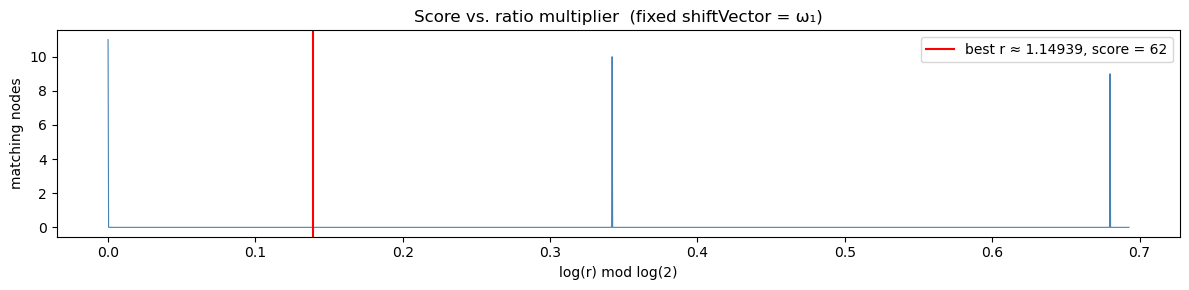

In [10]:
# Score landscape: coarse grid for visualisation
log_r_grid    = np.linspace(0, log2, 2000, endpoint=False)
scores_grid   = np.array([score_ratio(x) for x in log_r_grid])

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(log_r_grid, scores_grid, lw=0.8, color='steelblue')
for c in candidates[scores_cand == best_score]:
    ax.axvline(c, color='red', lw=1.2, alpha=0.7)
ax.axvline(best_log_r, color='red', lw=1.5,
           label=f'best r ≈ {best_r:.5f}, score = {best_score}')
ax.set_xlabel('log(r) mod log(2)')
ax.set_ylabel('matching nodes')
ax.set_title('Score vs. ratio multiplier  (fixed shiftVector = ω₁)')
ax.legend()
plt.tight_layout()
plt.show()

### The optimal multiplier is an exact 11-limit rational

Every candidate shift in the analytic enumeration has the form
$\log r = (\log t_j - \log R_i) \bmod \log 2$, i.e. $r = (t_j / R_i)\cdot 2^m$ where
both the target $t_j$ and the node ratio $R_i$ are 11-limit rationals.  The optimum is
therefore **guaranteed** to be an exact rational over $\{2, 3, 5, 7, 11\}$:

$$ r = \frac{1408}{1225} = \frac{2^7 \cdot 11}{5^2 \cdot 7^2}, $$

equivalently the exponent shift $(0, -2, -2, 0, +1)$ on the $(3, 5, 7, 9, 11)$ axes
plus seven octaves.  Because $r$ is rational it can be absorbed directly into the 5D
exponents — the approach developed in `he_rational_optimization.ipynb`.

In [11]:
# Recover the exact rational multiplier and verify it reproduces the optimum.
from fractions import Fraction

best_frac = Fraction(best_r).limit_denominator(2000)

def factorise_11limit(n):
    """Factor a positive integer over {2, 3, 5, 7, 11}; None if it doesn't factor."""
    f = {}
    for q in (2, 3, 5, 7, 11):
        while n % q == 0:
            f[q] = f.get(q, 0) + 1
            n //= q
    return f if n == 1 else None

num_f = factorise_11limit(best_frac.numerator)
den_f = factorise_11limit(best_frac.denominator)
assert num_f is not None and den_f is not None, 'best_r is not an 11-limit rational?'
assert abs((np.log(float(best_frac)) % log2) - best_log_r) < 1e-9
assert score_ratio(np.log(float(best_frac)) % log2) == best_score

fmt = lambda fac: ' · '.join(f'{q}^{e}' if e > 1 else f'{q}' for q, e in fac.items())
print(f'best_r exactly   = {best_frac}')
print(f'  factorisation  = ({fmt(num_f)}) / ({fmt(den_f)})')
print(f'  score          = {score_ratio(np.log(float(best_frac)) % log2)}  (== {best_score})')

best_r exactly   = 1408/1225
  factorisation  = (2^7 · 11) / (5^2 · 7^2)
  score          = 62  (== 62)


In [12]:
# Display matched nodes at best_log_r
shifted_best = (log_norm_fixed + best_log_r) % log2
diffs_best   = np.abs(shifted_best[:, None] - target_log_norm[None, :])
diffs_best   = np.minimum(diffs_best, log2 - diffs_best)
match_mask   = diffs_best.min(axis=1) < 1e-7

# Separate Diamond vs Eikosany — use same wraparound as score_ratio
diamond_log = np.log(diamond_float) % log2
eiko_log    = np.log(eiko_float)    % log2

def _circ_dists(a, b):
    d = np.abs(a[:, None] - b[None, :])
    return np.minimum(d, log2 - d)

d_dists = _circ_dists(shifted_best[match_mask], diamond_log)
e_dists = _circ_dists(shifted_best[match_mask], eiko_log)
d_idx_m = np.argmin(d_dists, axis=1)
e_idx_m = np.argmin(e_dists, axis=1)
is_d    = d_dists[np.arange(len(d_idx_m)), d_idx_m] < 1e-7
is_e    = e_dists[np.arange(len(e_idx_m)), e_idx_m] < 1e-7

print(f'Matched nodes at r = {best_r:.8f}  (score = {match_mask.sum()})')
print(f'{"pt":35s}  {"orig ratio":>12s}  {"×r ratio":>12s}  {"set":>8s}')
print('-' * 75)
for i, (pt, m_d, m_e) in enumerate(zip(sel_int_fixed[match_mask], is_d, is_e)):
    orig   = np.exp((pt @ log_rI) % log2)
    scaled = diamond_float[d_idx_m[i]] if m_d else eiko_float[e_idx_m[i]]
    member = ('Diamond' if m_d else '') + (' Eikosany' if m_e else '')
    print(f'{str(pt):35s}  {orig:12.6f}  {scaled:12.6f}  {member}')

Matched nodes at r = 1.14938776  (score = 62)
pt                                     orig ratio      ×r ratio       set
---------------------------------------------------------------------------
[ 0  3  2 -1 -2]                         1.406107      1.616162   Eikosany
[ 1  3  2 -1 -2]                         1.054580      1.212121   Eikosany
[-1  3  3 -1 -2]                         1.640458      1.885522   Eikosany
[ 0  3  3 -1 -2]                         1.230343      1.414141   Eikosany
[-1  2  2  0 -2]                         1.687328      1.939394   Eikosany
[-1  3  2  0 -2]                         1.054580      1.212121   Eikosany
[ 0  3  2  0 -2]                         1.581870      1.818182  Diamond
[-2  2  3  0 -2]                         1.968549      1.131313   Eikosany
[-1  2  3  0 -2]                         1.476412      1.696970   Eikosany
[-2  3  3  0 -2]                         1.230343      1.414141   Eikosany
[-1  3  3  0 -2]                         1.845515      1

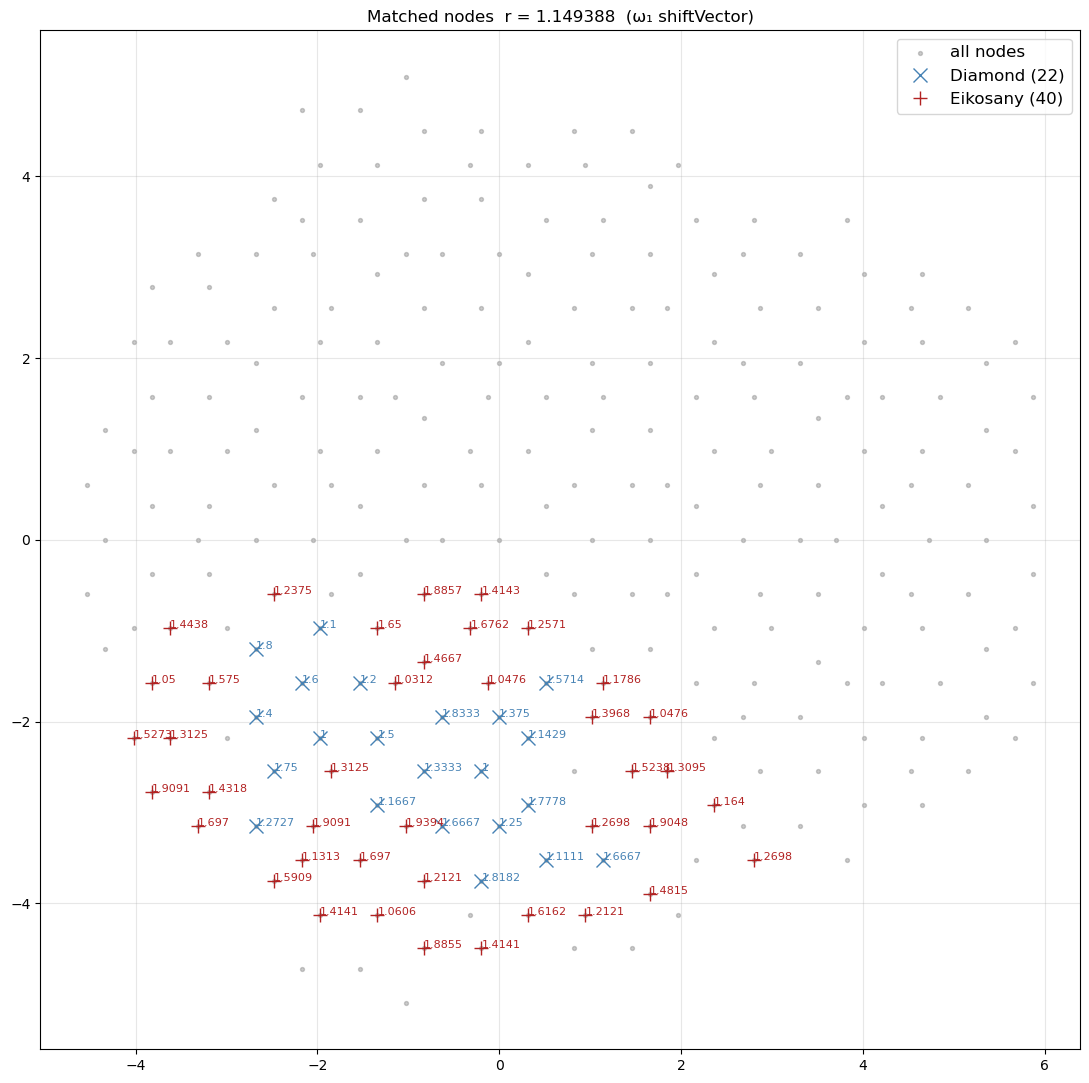

In [13]:
# Plot
xy_all   = (sel_int_fixed + sv_fixed) @ p.T
xy_match = xy_all[match_mask]
labels_m = [
    f'{diamond_float[d_idx_m[i]]:.5g}' if is_d[i] else f'{eiko_float[e_idx_m[i]]:.5g}'
    for i in range(match_mask.sum())
]

fig, ax = plt.subplots(figsize=(11, 11))
ax.scatter(xy_all[:, 0], xy_all[:, 1], s=8, color='grey', alpha=0.4, label='all nodes')
d_xy = xy_match[is_d]
e_xy = xy_match[is_e]
if len(d_xy):
    ax.plot(d_xy[:, 0], d_xy[:, 1], 'x', color='steelblue', markersize=10,
            label=f'Diamond ({is_d.sum()})', zorder=3)
if len(e_xy):
    ax.plot(e_xy[:, 0], e_xy[:, 1], '+', color='firebrick', markersize=10,
            label=f'Eikosany ({is_e.sum()})', zorder=3)
for i, lab in enumerate(labels_m):
    ax.annotate(lab, xy=xy_match[i], fontsize=8,
                color='steelblue' if is_d[i] else 'firebrick')
ax.legend(fontsize=12)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_title(f'Matched nodes  r = {best_r:.6f}  (ω₁ shiftVector)')
plt.tight_layout()
plt.show()

In [14]:
ji_data = {
    "freqRatioScalar": float(best_frac),   # exact rational (see rationality cell above)
    "freqRatioNum":    int(best_frac.numerator),
    "freqRatioDen":    int(best_frac.denominator),
    "diamondCount":    int(is_d.sum()),
    "diamondNodes":    xy_match[is_d].tolist(),
    "eikosanyCount":   int(is_e.sum()),
    "eikosanyNodes":   xy_match[is_e].tolist(),
}
out_path = '../Data/ji_membership.json'

with open(out_path, 'w') as f:
    json.dump(ji_data, f, indent=2)

print(f"Written to {out_path}")
print(f"Diamond: {ji_data['diamondCount']} nodes,  Eikosany: {ji_data['eikosanyCount']} nodes")

Written to ../Data/ji_membership.json
Diamond: 22 nodes,  Eikosany: 40 nodes


## Eikosany-only analytic enumeration (ω₁ shiftVector)

Repeat the analytic enumeration with Eikosany-only targets to find the best scalar multiplier
for Eikosany alignment — and determine whether the ω₁ slice has *any* affinity for the Eikosany,
or whether the Diamond preference is intrinsic to the minuscule-weight selection.

In [15]:
eiko_target_log = np.log(eiko_float) % log2   # Eikosany-only fingerprints

def score_ratio_eiko(log_r):
    shifted = (log_norm_fixed + log_r) % log2
    diffs   = np.abs(shifted[:, None] - eiko_target_log[None, :])
    diffs   = np.minimum(diffs, log2 - diffs)
    return int((diffs.min(axis=1) < 1e-7).sum())

# Analytic candidate shifts for Eikosany
cand_eiko   = ((eiko_target_log[None, :] - log_norm_fixed[:, None]) % log2).ravel()
cand_eiko   = np.unique(np.round(cand_eiko, decimals=10))
scores_eiko = np.array([score_ratio_eiko(c) for c in cand_eiko])

best_idx_e   = np.argmax(scores_eiko)
best_log_r_e = cand_eiko[best_idx_e]
best_score_e = scores_eiko[best_idx_e]
best_r_e     = np.exp(best_log_r_e)

print(f'Eikosany candidates evaluated: {len(cand_eiko)}')
print(f'Best Eikosany score          : {best_score_e} nodes')
print(f'Best multiplier r            = {best_r_e:.8f}')
print(f'  (log_r                     = {best_log_r_e:.8f})')
print(f'\nAll shifts achieving best Eikosany score:')
for c in cand_eiko[scores_eiko == best_score_e]:
    print(f'  r = {np.exp(c):.8f}  (log_r = {c:.8f})')

# Compare with Diamond best for reference
print(f'\n--- For comparison ---')
print(f'Best Diamond score  : {best_score} nodes  (r = {best_r:.8f})')

Eikosany candidates evaluated: 2901
Best Eikosany score          : 40 nodes
Best multiplier r            = 1.14938776
  (log_r                     = 0.13922941)

All shifts achieving best Eikosany score:
  r = 1.14938776  (log_r = 0.13922941)
  r = 1.32987013  (log_r = 0.28508129)

--- For comparison ---
Best Diamond score  : 62 nodes  (r = 1.14938776)


## Per-point `(1,1,1,1,1)` translation

`(1,1,1,1,1)` is in the kernel of the 2D Penrose projection (A₄ ⊥ (1,1,1,1,1)),
so adding integer multiples of it to a tiling node's 5D label leaves tile geometry
untouched but multiplies the JI ratio by `(3·5·7·9·11)^k = 10395^k` — equivalently
a fixed log-shift of `k · log(10395) mod log(2)` per unit `k`.

Allowing each node to independently choose its own `k` expands the membership search
beyond the single global scalar `r`.  For each (node `i`, integer `k ∈ [-K, K]`,
target `j`), the value of `log r` that puts node `i` exactly on target `j` is
`(target_j − log_norm[i] − k·log_uniform) mod log(2)`.  The score at any candidate
`log r` is the number of *distinct* nodes covered by some `(k, j)` pair — i.e. each
node may pick its own best `k` against the Diamond ∪ Eikosany target set.

In [16]:
log_uniform = log_rI.sum() % log2           # log(10395) mod log(2)
K_BOUND     = 5
k_range_k   = np.arange(-K_BOUND, K_BOUND + 1)

n_pts = len(log_norm_fixed)
n_k   = len(k_range_k)
n_t   = len(target_log_norm)

# (n_pts, n_k, n_t) array of candidate log_r values
log_r_arr = (
    target_log_norm[None, None, :]
    - log_norm_fixed[:, None, None]
    - k_range_k[None, :, None] * log_uniform
) % log2

log_r_flat = np.round(log_r_arr, decimals=10).ravel()
i_flat     = np.broadcast_to(np.arange(n_pts)[:, None, None], log_r_arr.shape).ravel()

# Score at each unique log_r = number of distinct point indices.  Numpy-only:
#   1) factorise log_r values into integer codes;
#   2) encode (code, i) as a single 64-bit integer;
#   3) dedup; bincount the resulting codes.
unique_r, r_codes = np.unique(log_r_flat, return_inverse=True)
ci_packed         = r_codes.astype(np.int64) * (n_pts + 1) + i_flat.astype(np.int64)
codes_per_pair    = np.unique(ci_packed) // (n_pts + 1)
scores_per_code   = np.bincount(codes_per_pair, minlength=len(unique_r))

best_code     = int(np.argmax(scores_per_code))
best_log_r_k  = float(unique_r[best_code])
best_score_k  = int(scores_per_code[best_code])
best_r_k      = float(np.exp(best_log_r_k))

print(f'K range scanned   : k ∈ [{-K_BOUND}, {K_BOUND}]')
print(f'Candidate log_r   : {len(log_r_flat):,d} total, {len(unique_r):,d} unique')
print(f'Best per-point-k score : {best_score_k} nodes   (vs. {best_score} with single global k)')
print(f'Best multiplier r = {best_r_k:.8f}   (log_r = {best_log_r_k:.8f})')

K range scanned   : k ∈ [-5, 5]
Candidate log_r   : 326,370 total, 25,275 unique
Best per-point-k score : 62 nodes   (vs. 62 with single global k)
Best multiplier r = 1.12510463   (log_r = 0.11787604)


Matched nodes     : 62
  Diamond          : 22
  Eikosany         : 40   (Eikosany-only: 40)
k distribution    : k=+3: 62


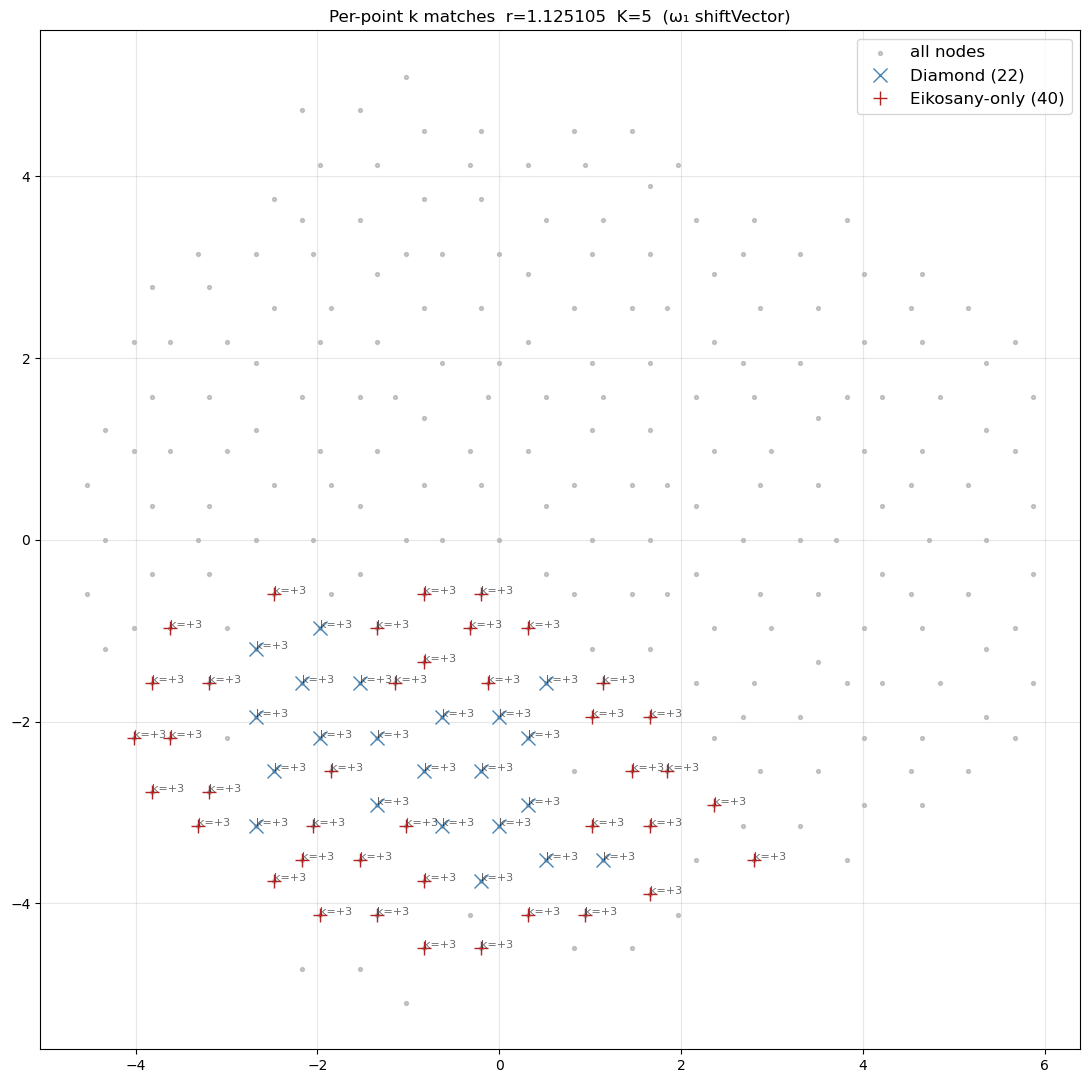

In [17]:
# For each point, find its best k at log_r = best_log_r_k.
log_norm_best       = (log_norm_fixed + best_log_r_k) % log2
best_k_per_pt       = np.zeros(n_pts, dtype=int)
best_dist_per_pt    = np.full(n_pts, np.inf)
best_target_per_pt  = np.full(n_pts, -1, dtype=int)

for k in k_range_k:
    shifted   = (log_norm_best + k * log_uniform) % log2
    diffs     = np.abs(shifted[:, None] - target_log_norm[None, :])
    diffs     = np.minimum(diffs, log2 - diffs)
    min_dist  = diffs.min(axis=1)
    better    = min_dist < best_dist_per_pt
    best_dist_per_pt[better]   = min_dist[better]
    best_k_per_pt[better]      = k
    best_target_per_pt[better] = diffs.argmin(axis=1)[better]

is_match_k = best_dist_per_pt < 1e-7

# Diamond vs Eikosany categorisation under the per-point-k matching
diamond_log_k = np.log(diamond_float) % log2
eiko_log_k    = np.log(eiko_float)    % log2
matched_idx   = np.where(is_match_k)[0]
match_log     = (log_norm_fixed[matched_idx]
                 + best_log_r_k
                 + best_k_per_pt[matched_idx] * log_uniform) % log2
is_d_k = _circ_dists(match_log, diamond_log_k).min(axis=1) < 1e-7
is_e_k = _circ_dists(match_log, eiko_log_k).min(axis=1) < 1e-7

k_unique, k_counts = np.unique(best_k_per_pt[is_match_k], return_counts=True)

print(f'Matched nodes     : {is_match_k.sum()}')
print(f'  Diamond          : {is_d_k.sum()}')
print(f'  Eikosany         : {is_e_k.sum()}   (Eikosany-only: {(is_e_k & ~is_d_k).sum()})')
print(f'k distribution    : ' + ', '.join(f'k={int(k):+d}: {int(c)}' for k, c in zip(k_unique, k_counts)))

# Visualisation
xy_all   = (sel_int_fixed + sv_fixed) @ p.T
xy_match = xy_all[matched_idx]

fig, ax = plt.subplots(figsize=(11, 11))
ax.scatter(xy_all[:, 0], xy_all[:, 1], s=8, color='grey', alpha=0.4, label='all nodes')

d_mask = is_d_k
e_only = is_e_k & ~is_d_k
if d_mask.any():
    ax.plot(xy_match[d_mask, 0], xy_match[d_mask, 1], 'x', color='steelblue',
            markersize=10, label=f'Diamond ({d_mask.sum()})', zorder=3)
if e_only.any():
    ax.plot(xy_match[e_only, 0], xy_match[e_only, 1], '+', color='firebrick',
            markersize=10, label=f'Eikosany-only ({e_only.sum()})', zorder=3)

for j, i in enumerate(matched_idx):
    if best_k_per_pt[i] != 0:
        ax.annotate(f'k={best_k_per_pt[i]:+d}', xy=xy_match[j],
                    fontsize=8, color='black', alpha=0.6)

ax.legend(fontsize=12)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_title(f'Per-point k matches  r={best_r_k:.6f}  K={K_BOUND}  (ω₁ shiftVector)')
plt.tight_layout()
plt.show()

**Interpretation.**  Per-node freedom in $k$ gives no improvement: 62 matches,
identical to the single global multiplier.  Moreover every matched node selects the
*same* $k = +3$, and the reported multiplier is the global optimum re-expressed:
$1.12510463 = (1408/1225)\,/\,10395^3$ octave-folded (verified to the 10-decimal
candidate rounding).  At this grid, the single scalar $r$ already captures all the
freedom the trace direction offers.

## HE-representability scan

Helmholtz-Ellis JI notation (as rendered by heji-ly) has per-prime exponent limits:
`|5-exp| ≤ 4`, `|7-exp| ≤ 2`, `|11-exp| ≤ 1`.  The 3- and 9-exponents are unconstrained
(9 = 3² folds into the 3-axis, which Pythagorean accidentals handle freely).

For each hull point at the ω₁ shiftVector we search over integer `k ∈ [-K, K]` for
the smallest `|k|` such that the shifted exponents `[a+k, b+k, c+k, d+k, e+k]` fit HE.
Three outcomes per point:

- **k = 0** — already HE-representable; no shift needed (preferred).
- **k ≠ 0** — representable after `(1,1,1,1,1)·k` translation.  The tile geometry is
  unchanged (A₄ ⊥ (1,1,1,1,1)) but the JI ratio shifts by `10395^k` — a *different*
  note at the same tile location.
- **infeasible** — no `k` in `[-K, K]` brings 7-exp into `[-2,2]` *and* 11-exp into
  `[-1,1]` simultaneously.  Typically these are points whose original 7-exp and 11-exp
  pull `k` in opposite directions.

In [18]:
def he_best_k(exps, k_max=20):
    """Smallest |k| such that (exps + k·(1,1,1,1,1)) fits HE limits
    (|5|<=4, |7|<=2, |11|<=1).  Returns the chosen k, or None."""
    for ak in range(0, k_max + 1):
        for kk in ((ak, -ak) if ak > 0 else (0,)):
            if he_representable([e + kk for e in exps]):
                return kk
    return None


K_HE_MAX = 20
n_hull   = len(sel_int_fixed)
he_k_vals = np.full(n_hull, np.nan)              # nan == infeasible
for i, pt in enumerate(sel_int_fixed):
    k = he_best_k(pt, k_max=K_HE_MAX)
    if k is not None:
        he_k_vals[i] = k

he_k0     = he_k_vals == 0
he_kshift = (~np.isnan(he_k_vals)) & (he_k_vals != 0)
he_skip   = np.isnan(he_k_vals)

from collections import Counter
nz_k_dist = sorted(Counter(int(k) for k in he_k_vals[he_kshift]).items())

print(f'Hull points (ω₁ shiftVector) : {n_hull}')
print(f'  HE-representable, k = 0    : {he_k0.sum()}')
print(f'  HE-representable, k != 0   : {he_kshift.sum()}   distribution: {nz_k_dist}')
print(f'  HE infeasible (|k|<={K_HE_MAX})   : {he_skip.sum()}')
print()
print('Infeasible exponent patterns (first 10):')
for pt in sel_int_fixed[he_skip][:10]:
    print(f'  {tuple(int(x) for x in pt)}')

Hull points (ω₁ shiftVector) : 258
  HE-representable, k = 0    : 116
  HE-representable, k != 0   : 55   distribution: [(-2, 7), (-1, 47), (1, 1)]
  HE infeasible (|k|<=20)   : 87

Infeasible exponent patterns (first 10):
  (-1, 3, 3, -1, -3)
  (-2, 3, 3, 0, -3)
  (-1, 3, 3, 0, -3)
  (0, 3, 2, -2, -2)
  (1, 3, 2, -2, -2)
  (-1, 3, 2, -1, -2)
  (0, 3, 2, -1, -2)
  (1, 3, 2, -1, -2)
  (-1, 3, 3, -1, -2)
  (0, 3, 3, -1, -2)


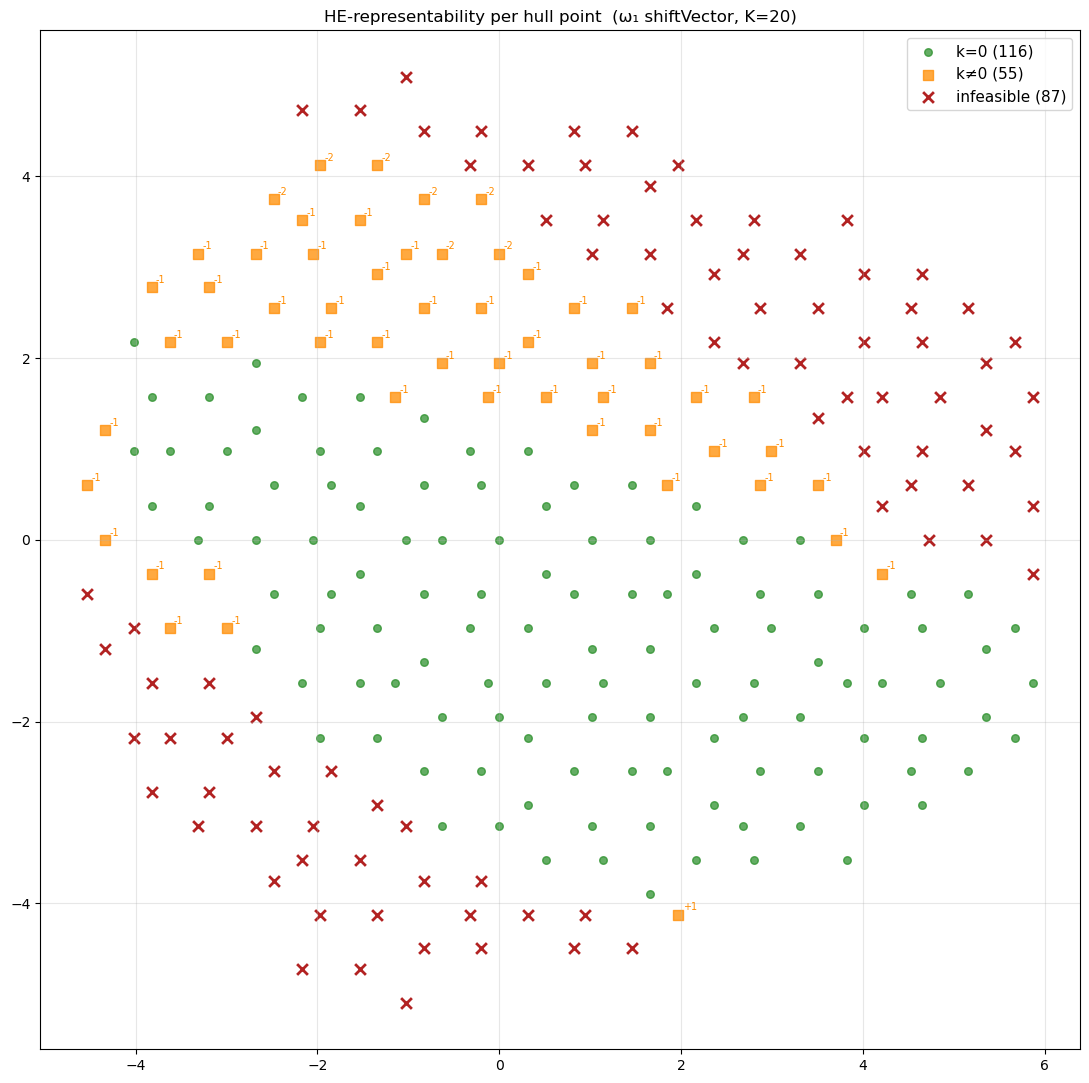

In [19]:
xy_all_he = (sel_int_fixed + sv_fixed) @ p.T

fig, ax = plt.subplots(figsize=(11, 11))
ax.scatter(xy_all_he[he_k0, 0],     xy_all_he[he_k0, 1],
           s=30, marker='o', color='forestgreen', alpha=0.7,
           label=f'k=0 ({he_k0.sum()})')
ax.scatter(xy_all_he[he_kshift, 0], xy_all_he[he_kshift, 1],
           s=45, marker='s', color='darkorange', alpha=0.75,
           label=f'k≠0 ({he_kshift.sum()})')
ax.scatter(xy_all_he[he_skip, 0],   xy_all_he[he_skip, 1],
           s=60, marker='x', color='firebrick', linewidth=2,
           label=f'infeasible ({he_skip.sum()})')

for i in np.where(he_kshift)[0]:
    ax.annotate(f'{int(he_k_vals[i]):+d}', xy=xy_all_he[i], fontsize=7,
                color='darkorange', xytext=(3, 3), textcoords='offset points')

ax.legend(fontsize=11, loc='upper right')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_title(f'HE-representability per hull point  (ω₁ shiftVector, K={K_HE_MAX})')
plt.tight_layout()
plt.show()